# 글로벌 경제 자산 분석
- `./data/asset` 에 저장된 각 자산별 CSV 데이터를 로딩·분석하고 하나의 통합 파일로 저장합니다.

| 자산 | 설명 | 티커 |
|------|------|------|
| 구리 | Copper Futures | HG=F |
| 금 | Gold Futures | GC=F |
| 반도체(SOX) | PHLX Semiconductor Index | SOX |
| 석유(WTI) | WTI Crude Oil Futures | CL=F |
| 해운운임(BDI) | Baltic Dry Index ETF | BDI |
| 미국 10년 국채 | US 10-Year Treasury Yield | TNX |
| 미국 CPI | Consumer Price Index | CPIAUCSL |

## 0. 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

BASE = os.path.join('data', 'asset')
OUT_DIR = os.path.join('data', 'analysis')
os.makedirs(OUT_DIR, exist_ok=True)
print('✅ 라이브러리 로딩 완료')

✅ 라이브러리 로딩 완료


## 1. 데이터 로딩 함수 정의

In [2]:
def load_yf_style(path, cols, skiprows, asset_label, enc='utf-8'):
    """yfinance 형식 CSV (멀티헤더 포함) 로딩 헬퍼."""
    df = pd.read_csv(path, encoding=enc, skiprows=skiprows, header=None, names=cols)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date']).set_index('Date')
    df = df.apply(pd.to_numeric, errors='coerce')
    df.columns = pd.MultiIndex.from_tuples([(c, asset_label) for c in df.columns])
    return df

def load_cpi(path, asset_label='미국CPI', enc='utf-8'):
    """월별 CPI 데이터 로딩."""
    df = pd.read_csv(path, encoding=enc, skiprows=1, header=None,
                     names=['Date', 'CPIAUCSL', 'CPI_YoY'])
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date']).set_index('Date')
    df = df.apply(pd.to_numeric, errors='coerce')
    df.columns = pd.MultiIndex.from_tuples([(c, asset_label) for c in df.columns])
    return df

print('✅ 함수 정의 완료')

✅ 함수 정의 완료


## 2. 구리 (Copper – HG=F)

In [3]:
copper = load_yf_style(
    path=os.path.join(BASE, '구리 (Copper)', 'copper_5yr_analysis_2026-03-28.csv'),
    cols=['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return'],
    skiprows=3,
    asset_label='구리(HG=F)'
)
print(f'구리 데이터: {copper.shape}  |  {copper.index[0].date()} ~ {copper.index[-1].date()}')
copper.head()

구리 데이터: (1259, 6)  |  2021-03-29 ~ 2026-03-27


,Close,High,Low,Open,Volume,Daily_Return
,구리(HG=F),구리(HG=F),구리(HG=F),구리(HG=F),구리(HG=F),구리(HG=F)
Date,,,,,,
2021-03-29,4.0430,4.0690,4.020,4.0650,441,NaN
2021-03-30,3.9830,4.0355,3.975,4.0355,1052,-1.484051
2021-03-31,4.0030,4.0115,3.989,4.0060,289,0.502128
2021-04-01,4.0035,4.0150,3.985,3.9850,815,0.012496
2021-04-05,4.1490,4.1620,4.054,4.0540,243,3.634325


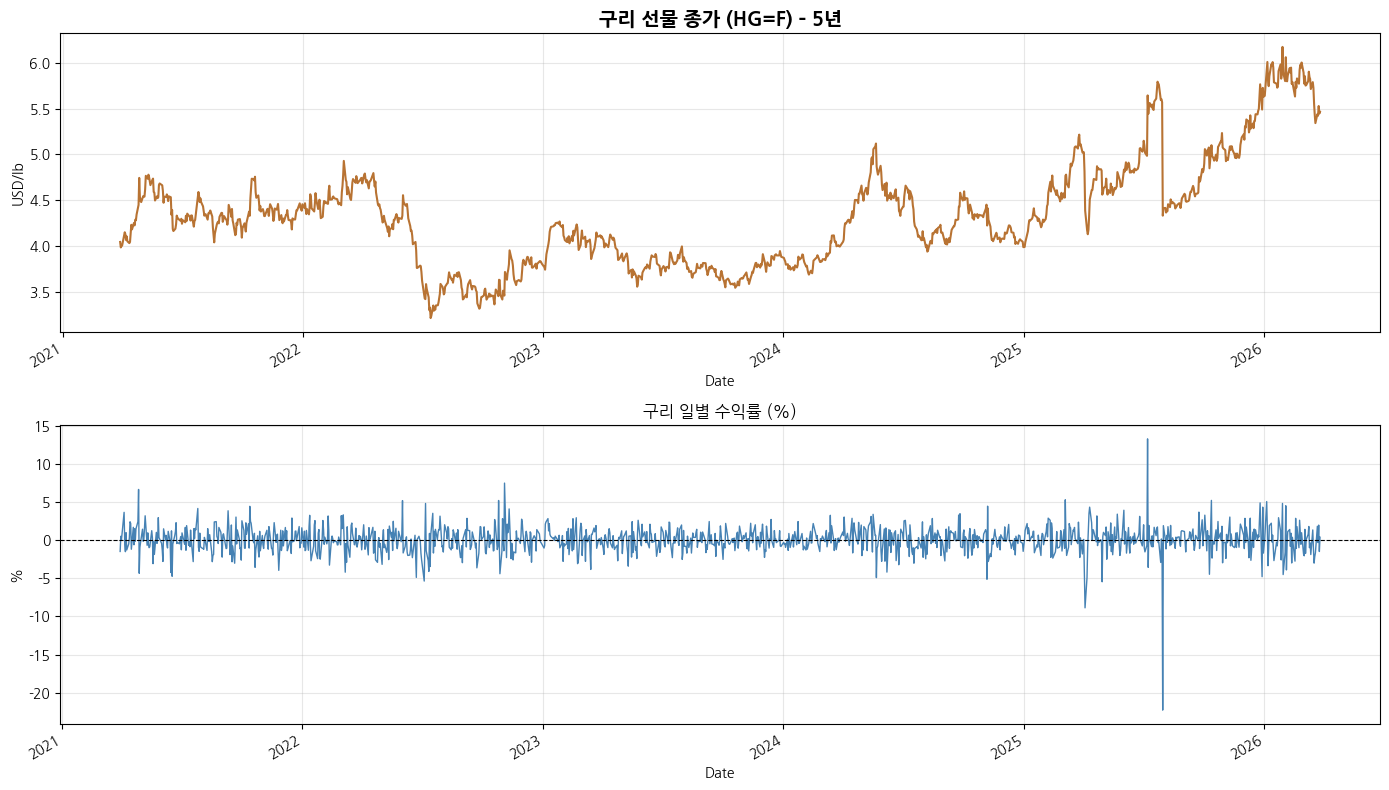

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
copper[('Close', '구리(HG=F)')].plot(ax=axes[0], color='#B87333', linewidth=1.5)
axes[0].set_title('구리 선물 종가 (HG=F) – 5년', fontsize=14, fontweight='bold')
axes[0].set_ylabel('USD/lb')

copper[('Daily_Return', '구리(HG=F)')].plot(ax=axes[1], color='steelblue', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('구리 일별 수익률 (%)')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

In [5]:
copper.describe()

,Close,High,Low,Open,Volume,Daily_Return
,구리(HG=F),구리(HG=F),구리(HG=F),구리(HG=F),구리(HG=F),구리(HG=F)
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1258.000000
mean,4.321149,4.351932,4.286131,4.319353,1448.098491,0.039827
std,0.570947,0.578596,0.559301,0.569096,4775.832732,1.763359
min,3.210500,3.254000,3.150000,3.154000,0.000000,-22.253142
25%,3.869500,3.889500,3.842250,3.863750,428.500000,-0.935219
50%,4.281000,4.314000,4.253500,4.280500,611.000000,0.023842
75%,4.586500,4.620000,4.544000,4.580750,892.500000,1.038464
max,6.175500,6.508000,6.131500,6.157000,55975.000000,13.251080


## 3. 금 (Gold – GC=F)

In [6]:
gold = load_yf_style(
    path=os.path.join(BASE, '금 (Gold)', 'gold_5yr_analysis_2026-03-28.csv'),
    cols=['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA20', 'MA60'],
    skiprows=3,
    asset_label='금(GC=F)'
)
print(f'금 데이터: {gold.shape}  |  {gold.index[0].date()} ~ {gold.index[-1].date()}')
gold.head()

금 데이터: (1258, 8)  |  2021-03-29 ~ 2026-03-27


,Close,High,Low,Open,Volume,Daily_Return,MA20,MA60
,금(GC=F),금(GC=F),금(GC=F),금(GC=F),금(GC=F),금(GC=F),금(GC=F),금(GC=F)
Date,,,,,,,,
2021-03-29,1712.099976,1712.099976,1712.099976,1712.099976,135457,NaN,NaN,NaN
2021-03-30,1683.900024,1712.599976,1676.500000,1711.000000,25316,-1.647097,NaN,NaN
2021-03-31,1713.800049,1713.800049,1676.500000,1683.699951,762,1.775641,NaN,NaN
2021-04-01,1726.500000,1728.800049,1706.400024,1706.800049,720,0.741040,NaN,NaN
2021-04-05,1727.000000,1729.699951,1721.900024,1727.900024,275,0.028960,NaN,NaN


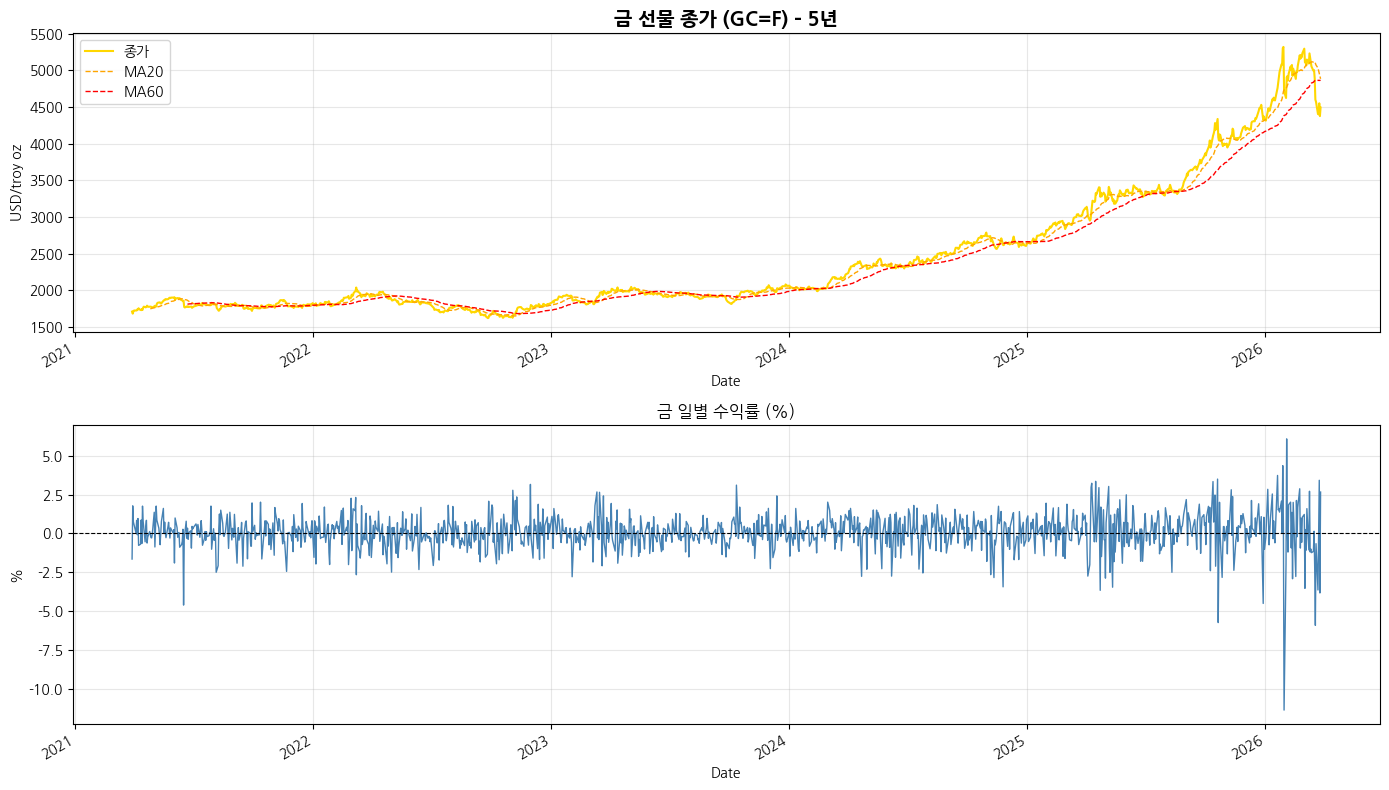

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

gold[('Close', '금(GC=F)')].plot(ax=axes[0], color='#FFD700', linewidth=1.5, label='종가')
gold[('MA20', '금(GC=F)')].plot(ax=axes[0], color='orange', linewidth=1, linestyle='--', label='MA20')
gold[('MA60', '금(GC=F)')].plot(ax=axes[0], color='red', linewidth=1, linestyle='--', label='MA60')
axes[0].set_title('금 선물 종가 (GC=F) – 5년', fontsize=14, fontweight='bold')
axes[0].set_ylabel('USD/troy oz')
axes[0].legend()

gold[('Daily_Return', '금(GC=F)')].plot(ax=axes[1], color='steelblue', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('금 일별 수익률 (%)')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

## 4. 반도체 지수 (SOX)

In [8]:
sox = load_yf_style(
    path=os.path.join(BASE, '반도체 가격 (DRAM, NAND)', 'sox_index_5yr_korean.csv'),
    cols=['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA20', 'MA60'],
    skiprows=1,
    asset_label='반도체(SOX)'
)
print(f'반도체 데이터: {sox.shape}  |  {sox.index[0].date()} ~ {sox.index[-1].date()}')
sox.head()

반도체 데이터: (1256, 8)  |  2021-03-29 ~ 2026-03-27


,Close,High,Low,Open,Volume,Daily_Return,MA20,MA60
,반도체(SOX),반도체(SOX),반도체(SOX),반도체(SOX),반도체(SOX),반도체(SOX),반도체(SOX),반도체(SOX)
Date,,,,,,,,
2021-03-29,3054.629883,3085.629883,3021.979980,3077.149902,0,NaN,NaN,NaN
2021-03-30,3044.550049,3055.750000,3013.270020,3034.800049,0,-0.329985,NaN,NaN
2021-03-31,3124.939941,3147.050049,3072.540039,3073.469971,0,2.640452,NaN,NaN
2021-04-01,3240.169922,3242.330078,3180.479980,3187.290039,0,3.687430,NaN,NaN
2021-04-05,3305.429932,3314.159912,3255.280029,3282.909912,0,2.014092,NaN,NaN


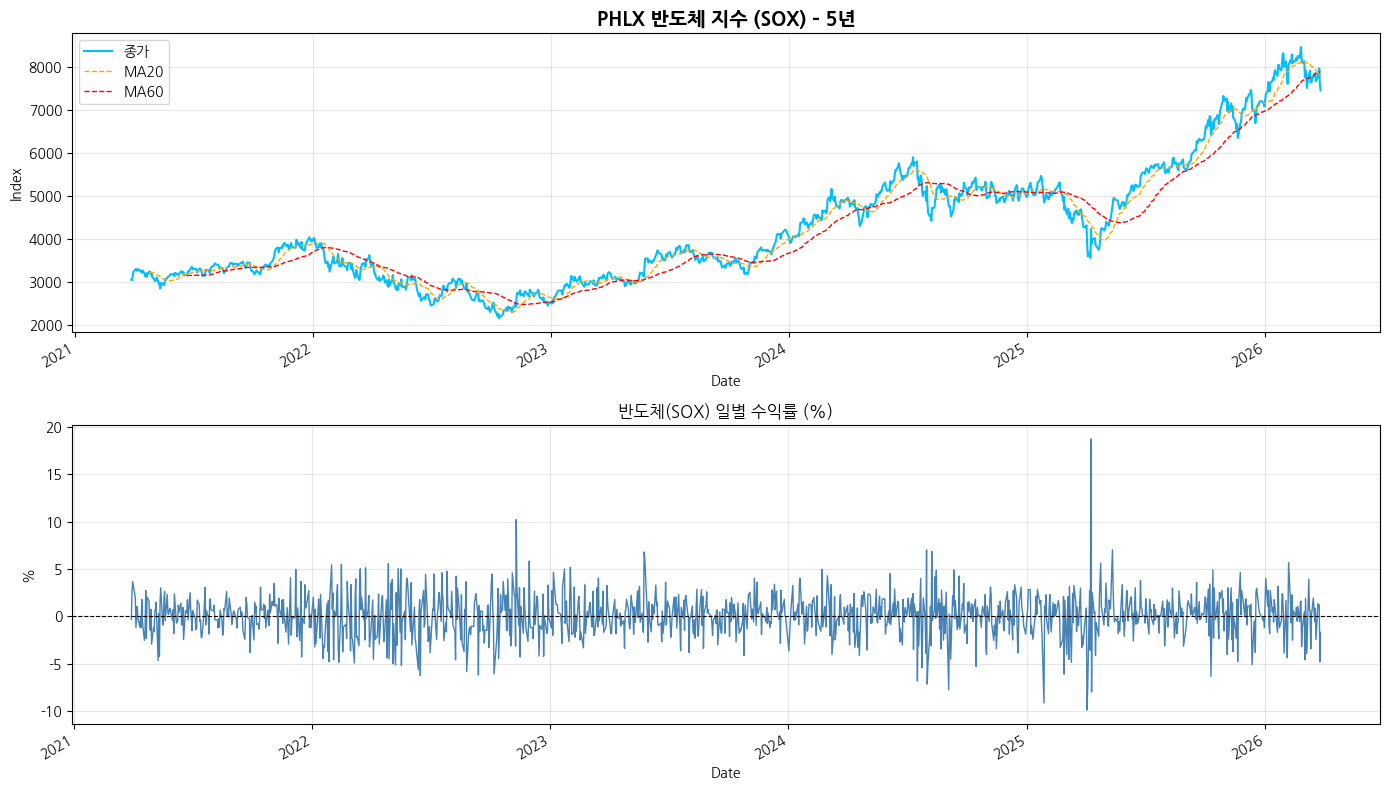

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

sox[('Close', '반도체(SOX)')].plot(ax=axes[0], color='#00BFFF', linewidth=1.5, label='종가')
sox[('MA20', '반도체(SOX)')].plot(ax=axes[0], color='orange', linewidth=1, linestyle='--', label='MA20')
sox[('MA60', '반도체(SOX)')].plot(ax=axes[0], color='red', linewidth=1, linestyle='--', label='MA60')
axes[0].set_title('PHLX 반도체 지수 (SOX) – 5년', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Index')
axes[0].legend()

sox[('Daily_Return', '반도체(SOX)')].plot(ax=axes[1], color='steelblue', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('반도체(SOX) 일별 수익률 (%)')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

## 5. 석유 (WTI Crude Oil)

In [10]:
oil = load_yf_style(
    path=os.path.join(BASE, '석유 (Crude Oil)', 'wti_oil_5yr_data.csv'),
    cols=['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA20', 'MA60'],
    skiprows=1,
    asset_label='석유(WTI)'
)
print(f'석유 데이터: {oil.shape}  |  {oil.index[0].date()} ~ {oil.index[-1].date()}')
oil.head()

석유 데이터: (1258, 8)  |  2021-03-29 ~ 2026-03-27


,Close,High,Low,Open,Volume,Daily_Return,MA20,MA60
,석유(WTI),석유(WTI),석유(WTI),석유(WTI),석유(WTI),석유(WTI),석유(WTI),석유(WTI)
Date,,,,,,,,
2021-03-29,61.560001,61.770000,59.410000,60.930000,449360,NaN,NaN,NaN
2021-03-30,60.549999,62.270000,59.939999,61.959999,388188,-1.640679,NaN,NaN
2021-03-31,59.160000,61.169998,58.849998,60.450001,414162,-2.295622,NaN,NaN
2021-04-01,61.450001,61.750000,58.860001,59.490002,605567,3.870860,NaN,NaN
2021-04-05,58.650002,61.500000,57.630001,61.500000,438864,-4.556549,NaN,NaN


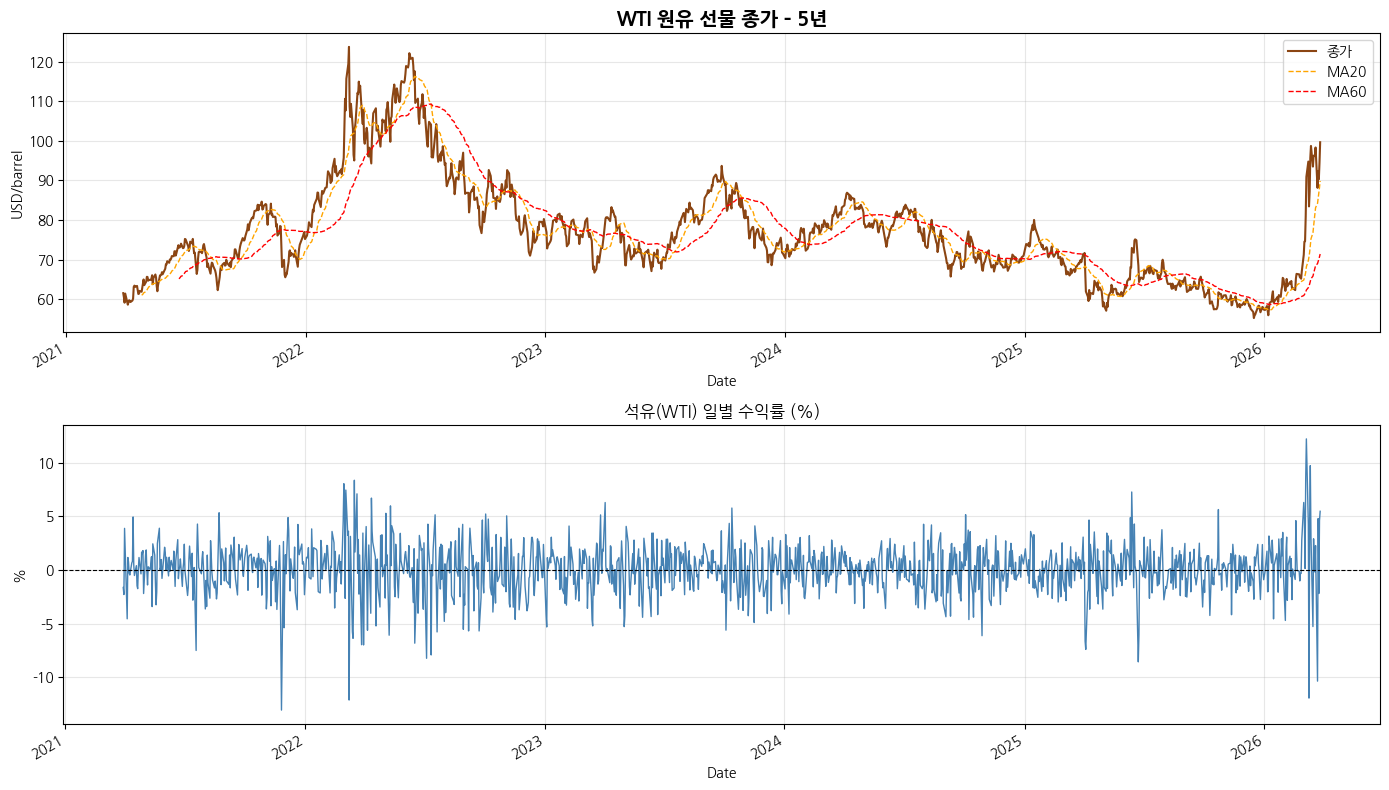

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

oil[('Close', '석유(WTI)')].plot(ax=axes[0], color='#8B4513', linewidth=1.5, label='종가')
oil[('MA20', '석유(WTI)')].plot(ax=axes[0], color='orange', linewidth=1, linestyle='--', label='MA20')
oil[('MA60', '석유(WTI)')].plot(ax=axes[0], color='red', linewidth=1, linestyle='--', label='MA60')
axes[0].set_title('WTI 원유 선물 종가 – 5년', fontsize=14, fontweight='bold')
axes[0].set_ylabel('USD/barrel')
axes[0].legend()

oil[('Daily_Return', '석유(WTI)')].plot(ax=axes[1], color='steelblue', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('석유(WTI) 일별 수익률 (%)')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

## 6. 해운 운임 지수 (BDI)

In [12]:
bdi = load_yf_style(
    path=os.path.join(BASE, '해운 운임 지수 (BDI, SCFI)', 'shipping_index_5yr.csv'),
    cols=['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA20', 'MA120'],
    skiprows=1,
    asset_label='해운운임(BDI)'
)
print(f'해운 데이터: {bdi.shape}  |  {bdi.index[0].date()} ~ {bdi.index[-1].date()}')
bdi.head()

해운 데이터: (1256, 8)  |  2021-03-29 ~ 2026-03-27


,Close,High,Low,Open,Volume,Daily_Return,MA20,MA120
,해운운임(BDI),해운운임(BDI),해운운임(BDI),해운운임(BDI),해운운임(BDI),해운운임(BDI),해운운임(BDI),해운운임(BDI)
Date,,,,,,,,
2021-03-29,16.870001,17.879999,16.65,17.879999,248400,NaN,NaN,NaN
2021-03-30,16.500000,16.500000,16.17,16.180000,180100,-2.193247,NaN,NaN
2021-03-31,16.920000,17.000000,16.27,16.270000,171000,2.545455,NaN,NaN
2021-04-01,17.930000,18.020000,17.33,17.400000,185500,5.969268,NaN,NaN
2021-04-05,18.209999,18.270000,17.68,18.139999,677200,1.561622,NaN,NaN


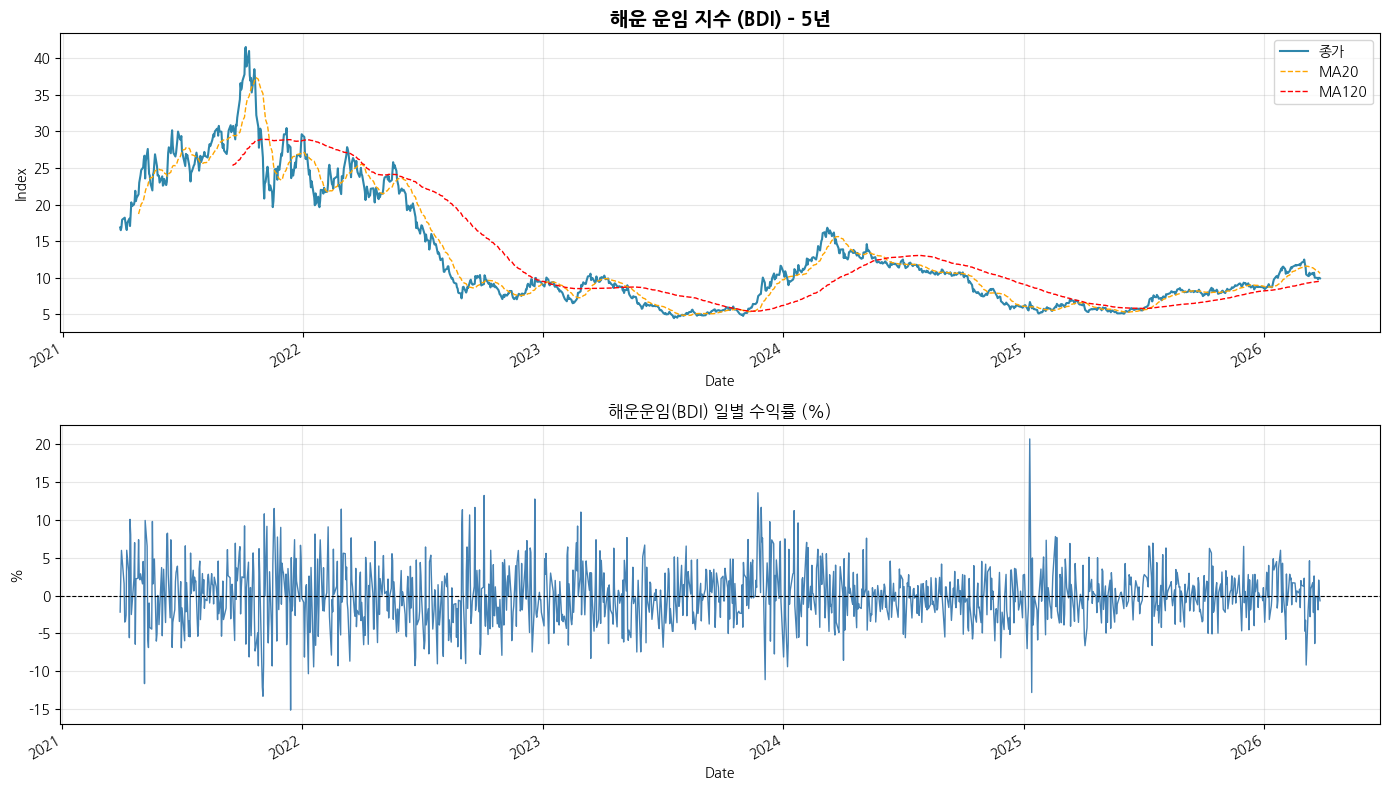

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

bdi[('Close', '해운운임(BDI)')].plot(ax=axes[0], color='#2E86AB', linewidth=1.5, label='종가')
bdi[('MA20', '해운운임(BDI)')].plot(ax=axes[0], color='orange', linewidth=1, linestyle='--', label='MA20')
bdi[('MA120', '해운운임(BDI)')].plot(ax=axes[0], color='red', linewidth=1, linestyle='--', label='MA120')
axes[0].set_title('해운 운임 지수 (BDI) – 5년', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Index')
axes[0].legend()

bdi[('Daily_Return', '해운운임(BDI)')].plot(ax=axes[1], color='steelblue', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('해운운임(BDI) 일별 수익률 (%)')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

## 7. 현금 자산 – 미국 10년 국채 & CPI

In [14]:
tnx = load_yf_style(
    path=os.path.join(BASE, '현금 (Cash)', 'us_10y_treasury_5yr.csv'),
    cols=['Date', 'Close', 'High', 'Low', 'Open', 'Volume'],
    skiprows=1,
    asset_label='미국10년국채(TNX)'
)
tnx = tnx.drop(columns=[('Volume', '미국10년국채(TNX)')], errors='ignore')
print(f'국채 데이터: {tnx.shape}  |  {tnx.index[0].date()} ~ {tnx.index[-1].date()}')

cpi = load_cpi(
    path=os.path.join(BASE, '현금 (Cash)', 'us_cpi_5yr_final.csv')
)
print(f'CPI 데이터: {cpi.shape}  |  {cpi.index[0].date()} ~ {cpi.index[-1].date()}')
cpi.tail()

국채 데이터: (1255, 4)  |  2021-03-30 ~ 2026-03-27
CPI 데이터: (59, 2)  |  2021-04-01 ~ 2026-02-01


,CPIAUCSL,CPI_YoY
,미국CPI,미국CPI
Date,,
2025-10-01,NaN,NaN
2025-11-01,325.063,2.696444
2025-12-01,326.031,2.653304
2026-01-01,326.588,2.391201
2026-02-01,327.460,2.434004


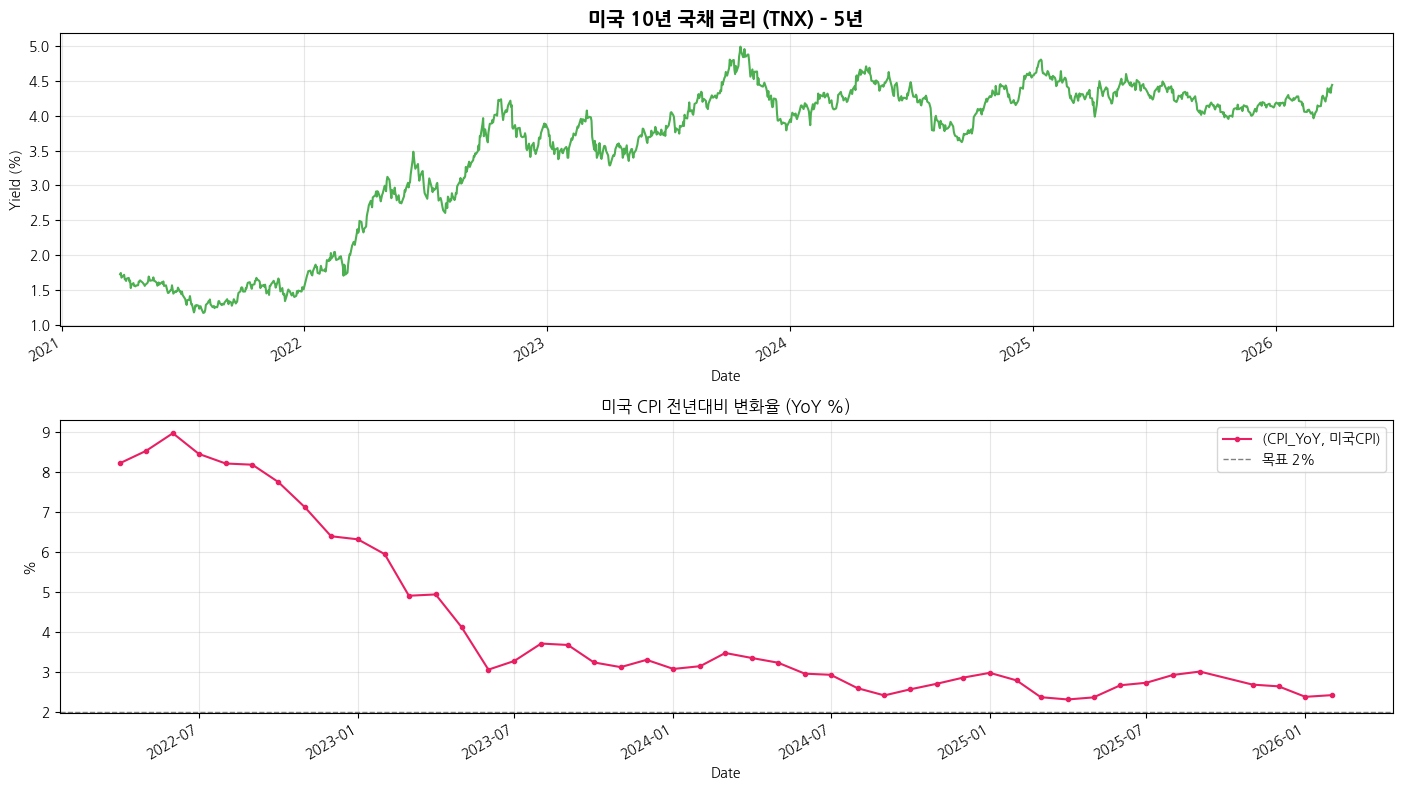

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

tnx[('Close', '미국10년국채(TNX)')].plot(ax=axes[0], color='#4CAF50', linewidth=1.5)
axes[0].set_title('미국 10년 국채 금리 (TNX) – 5년', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Yield (%)')

cpi[('CPI_YoY', '미국CPI')].dropna().plot(ax=axes[1], color='#E91E63', linewidth=1.5, marker='o', markersize=3)
axes[1].axhline(2.0, color='gray', linestyle='--', linewidth=1, label='목표 2%')
axes[1].set_title('미국 CPI 전년대비 변화율 (YoY %)')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. 전체 자산 통합 및 저장

**저장 파일**
1. `asset_combined_close.csv` – Close 가격만 (wide 형태, 자산별 컬럼)
2. `asset_combined_all.csv` – 모든 지표 포함 (MultiIndex 컬럼을 flat 처리)

In [16]:
# 각 자산의 Close 가격만 추출해서 wide 형태로 병합
dfs_close = [
    copper[('Close', '구리(HG=F)')].rename('구리(HG=F)'),
    gold[('Close', '금(GC=F)')].rename('금(GC=F)'),
    sox[('Close', '반도체(SOX)')].rename('반도체(SOX)'),
    oil[('Close', '석유(WTI)')].rename('석유(WTI)'),
    bdi[('Close', '해운운임(BDI)')].rename('해운운임(BDI)'),
    tnx[('Close', '미국10년국채(TNX)')].rename('미국10년국채(TNX)'),
    cpi[('CPIAUCSL', '미국CPI')].rename('미국CPI_CPIAUCSL'),
    cpi[('CPI_YoY', '미국CPI')].rename('미국CPI_YoY'),
]

df_close = pd.concat(dfs_close, axis=1).sort_index()
df_close.index.name = 'Date'

print(f'통합 Close 데이터: {df_close.shape}')
print(f'날짜 범위: {df_close.index[0].date()} ~ {df_close.index[-1].date()}')
df_close.tail(5)

통합 Close 데이터: (1280, 8)
날짜 범위: 2021-03-29 ~ 2026-03-27


,구리(HG=F),금(GC=F),반도체(SOX),석유(WTI),해운운임(BDI),미국10년국채(TNX),미국CPI_CPIAUCSL,미국CPI_YoY
Date,,,,,,,,
2026-03-23,5.4395,4404.100098,7773.129883,88.129997,9.99,4.334,NaN,NaN
2026-03-24,5.4225,4399.299805,7872.709961,92.349998,9.80,4.392,NaN,NaN
2026-03-25,5.5290,4549.799805,7967.750000,90.320000,10.00,4.328,NaN,NaN
2026-03-26,5.4465,4375.500000,7585.870117,94.480003,10.00,4.416,NaN,NaN
2026-03-27,5.4670,4492.000000,7457.669922,99.639999,9.93,4.440,NaN,NaN


In [17]:
# 전체 지표 통합 (MultiIndex → flat 컬럼명)
df_all = copper.copy()
for df in [gold, sox, oil, bdi, tnx, cpi]:
    df_all = df_all.join(df, how='outer')

df_all = df_all.sort_index()

# MultiIndex 컬럼을 '지표_자산' 형태로 flatten
df_all.columns = [f"{metric}_{asset}" for metric, asset in df_all.columns]
df_all.index.name = 'Date'

print(f'통합 전체 데이터: {df_all.shape}')
print('컬럼 목록:')
for c in df_all.columns:
    print(f'  - {c}')

통합 전체 데이터: (1280, 44)
컬럼 목록:
  - Close_구리(HG=F)
  - High_구리(HG=F)
  - Low_구리(HG=F)
  - Open_구리(HG=F)
  - Volume_구리(HG=F)
  - Daily_Return_구리(HG=F)
  - Close_금(GC=F)
  - High_금(GC=F)
  - Low_금(GC=F)
  - Open_금(GC=F)
  - Volume_금(GC=F)
  - Daily_Return_금(GC=F)
  - MA20_금(GC=F)
  - MA60_금(GC=F)
  - Close_반도체(SOX)
  - High_반도체(SOX)
  - Low_반도체(SOX)
  - Open_반도체(SOX)
  - Volume_반도체(SOX)
  - Daily_Return_반도체(SOX)
  - MA20_반도체(SOX)
  - MA60_반도체(SOX)
  - Close_석유(WTI)
  - High_석유(WTI)
  - Low_석유(WTI)
  - Open_석유(WTI)
  - Volume_석유(WTI)
  - Daily_Return_석유(WTI)
  - MA20_석유(WTI)
  - MA60_석유(WTI)
  - Close_해운운임(BDI)
  - High_해운운임(BDI)
  - Low_해운운임(BDI)
  - Open_해운운임(BDI)
  - Volume_해운운임(BDI)
  - Daily_Return_해운운임(BDI)
  - MA20_해운운임(BDI)
  - MA120_해운운임(BDI)
  - Close_미국10년국채(TNX)
  - High_미국10년국채(TNX)
  - Low_미국10년국채(TNX)
  - Open_미국10년국채(TNX)
  - CPIAUCSL_미국CPI
  - CPI_YoY_미국CPI


In [18]:
# ── 저장 ──────────────────────────────────────
close_path = os.path.join(OUT_DIR, 'asset_combined_close.csv')
all_path = os.path.join(OUT_DIR, 'asset_combined_all.csv')

df_close.to_csv(close_path, encoding='utf-8-sig')
df_all.to_csv(all_path, encoding='utf-8-sig')

print(f'✅ Close 가격 통합 파일 저장: {close_path}')
print(f'✅ 전체 지표 통합 파일 저장: {all_path}')
print()
print(f'  - asset_combined_close.csv : {df_close.shape[0]:,}행 × {df_close.shape[1]}열')
print(f'  - asset_combined_all.csv   : {df_all.shape[0]:,}행 × {df_all.shape[1]}열')

✅ Close 가격 통합 파일 저장: data\analysis\asset_combined_close.csv
✅ 전체 지표 통합 파일 저장: data\analysis\asset_combined_all.csv

  - asset_combined_close.csv : 1,280행 × 8열
  - asset_combined_all.csv   : 1,280행 × 44열


## 9. 자산 간 상관관계 분석

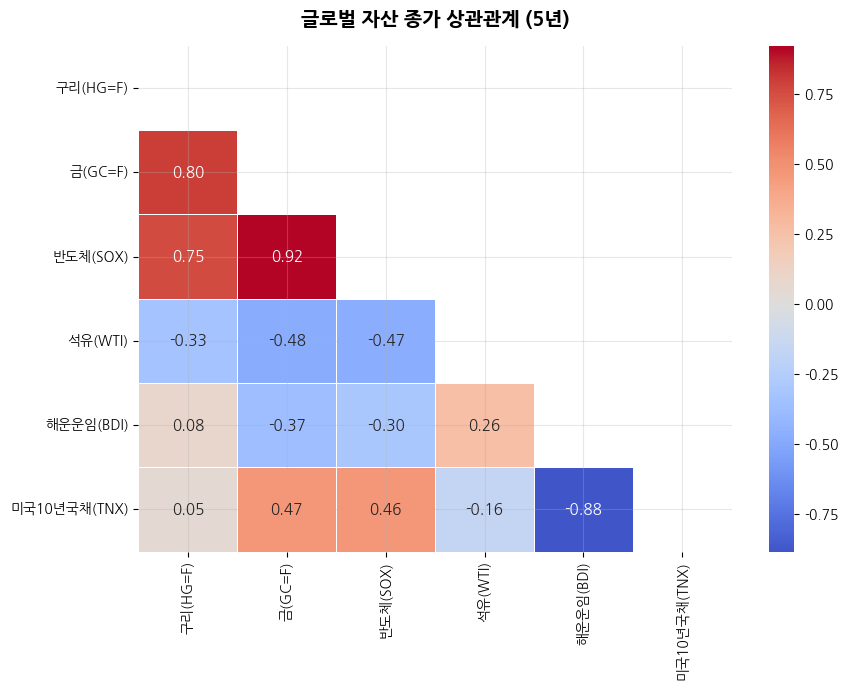


상관계수 행렬:


,구리(HG=F),금(GC=F),반도체(SOX),석유(WTI),해운운임(BDI),미국10년국채(TNX)
구리(HG=F),1.000000,0.796727,0.754738,-0.332043,0.083344,0.051003
금(GC=F),0.796727,1.000000,0.921338,-0.475404,-0.373512,0.467700
반도체(SOX),0.754738,0.921338,1.000000,-0.474169,-0.303545,0.463511
석유(WTI),-0.332043,-0.475404,-0.474169,1.000000,0.264801,-0.164400
해운운임(BDI),0.083344,-0.373512,-0.303545,0.264801,1.000000,-0.883974
미국10년국채(TNX),0.051003,0.467700,0.463511,-0.164400,-0.883974,1.000000


In [23]:
import seaborn as sns

# 일별 데이터가 있는 Close 컬럼만 상관 계산
corr_cols = ['구리(HG=F)', '금(GC=F)', '반도체(SOX)', '석유(WTI)', '해운운임(BDI)', '미국10년국채(TNX)']
corr_df = df_close[corr_cols].dropna()
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, mask=mask, 
            ax=ax, linewidths=0.5,
            annot_kws={'size': 11})
ax.set_title('글로벌 자산 종가 상관관계 (5년)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\n상관계수 행렬:')
corr

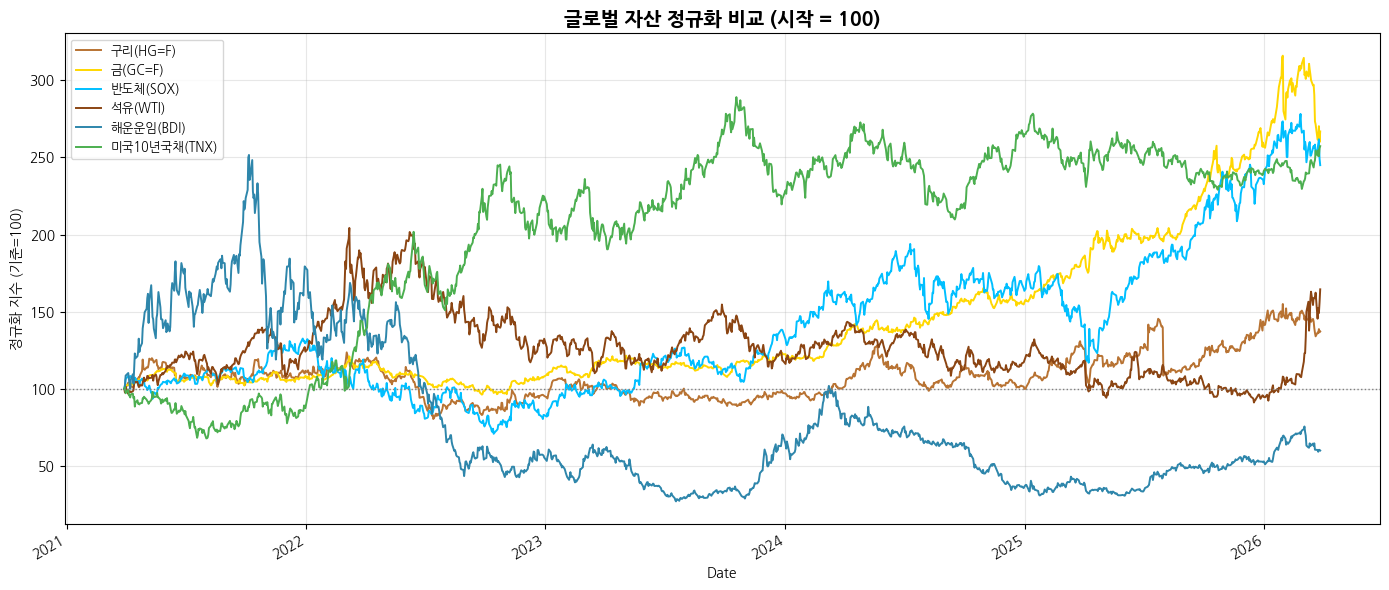

In [20]:
# 정규화(시작=100 기준) 비교 차트
norm = corr_df / corr_df.bfill().iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#B87333', '#FFD700', '#00BFFF', '#8B4513', '#2E86AB', '#4CAF50']
for col, color in zip(norm.columns, colors):
    norm[col].plot(ax=ax, linewidth=1.4, label=col, color=color)

ax.axhline(100, color='gray', linestyle=':', linewidth=1)
ax.set_title('글로벌 자산 정규화 비교 (시작 = 100)', fontsize=14, fontweight='bold')
ax.set_ylabel('정규화 지수 (기준=100)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 10. 저장 결과 확인

In [21]:
print('=== 저장된 파일 목록 ===')
for f in os.listdir(OUT_DIR):
    fp = os.path.join(OUT_DIR, f)
    size_kb = os.path.getsize(fp) / 1024
    print(f'  {f:40s}  {size_kb:>8.1f} KB')

print()
print('=== asset_combined_close.csv 미리보기 (마지막 5행) ===')
preview = pd.read_csv(close_path, encoding='utf-8-sig', index_col='Date', parse_dates=True)
print(preview.tail(5).to_string())
print()
print('=== 기술통계 ===')
preview.describe().round(2)

=== 저장된 파일 목록 ===
  asset_combined_all.csv                       850.1 KB
  asset_combined_close.csv                     145.2 KB
  it                                             4.0 KB

=== asset_combined_close.csv 미리보기 (마지막 5행) ===
            구리(HG=F)      금(GC=F)     반도체(SOX)    석유(WTI)  해운운임(BDI)  미국10년국채(TNX)  미국CPI_CPIAUCSL  미국CPI_YoY
Date                                                                                                         
2026-03-23    5.4395  4404.100098  7773.129883  88.129997       9.99         4.334             NaN        NaN
2026-03-24    5.4225  4399.299805  7872.709961  92.349998       9.80         4.392             NaN        NaN
2026-03-25    5.5290  4549.799805  7967.750000  90.320000      10.00         4.328             NaN        NaN
2026-03-26    5.4465  4375.500000  7585.870117  94.480003      10.00         4.416             NaN        NaN
2026-03-27    5.4670  4492.000000  7457.669922  99.639999       9.93         4.440             NaN        

,구리(HG=F),금(GC=F),반도체(SOX),석유(WTI),해운운임(BDI),미국10년국채(TNX),미국CPI_CPIAUCSL,미국CPI_YoY
count,1259.00,1258.00,1256.00,1258.00,1256.00,1255.00,58.00,46.00
mean,4.32,2420.39,4253.82,76.72,12.90,3.50,303.25,4.16
std,0.57,859.58,1414.69,12.70,7.89,1.07,16.97,2.11
min,3.21,1623.30,2162.32,55.27,4.50,1.17,266.61,2.33
25%,3.87,1823.93,3176.67,68.28,7.37,2.93,294.92,2.73
50%,4.28,1983.65,3755.91,74.59,9.76,3.98,306.68,3.15
75%,4.59,2713.40,5091.57,82.41,16.80,4.27,316.30,4.94
max,6.18,5318.40,8467.43,123.70,41.51,4.99,327.46,8.98
